# Challenge 2 — Financial Health Classification

## Objective
The goal is to classify Italian companies into four financial health categories:

- **A** = excellent
- **B** = good
- **C** = fair
- **D** = poor

This is a **multiclass classification** task, but also an **ordinal** one:
A > B > C > D.

## Business motivation
This rating system mirrors real-world credit risk assessment and allows creditors, investors, and business partners to evaluate firm stability and creditworthiness.

## Main technical implications
This challenge has three important properties:

1. **Class imbalance**
2. **Ordinal structure**
3. **Asymmetric misclassification costs**

Predicting A when the true class is D is much worse than confusing B and C.

## Evaluation
Primary metric:
- **Weighted F1-score**

Additional diagnostics:
- Macro F1-score
- Confusion matrix
- Per-class precision and recall
- Ordinal distance error

## Validation strategy
To avoid leakage, we use a **temporal split**:
- **Train**: 2018–2020
- **Validation**: 2021

All preprocessing steps are fit **only on the training set** and then applied to validation.

In [56]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

from pathlib import Path
output_path = Path("../data/final")
output_path.mkdir(parents=True, exist_ok=True)
submission.to_csv(output_path / "challenge2_submission.csv", index=False)

print("Saved in:", output_path / "challenge2_submission.csv")
SEED = 42
np.random.seed(SEED)

TARGET = "financial_health_class"
CLASS_ORDER = ["A", "B", "C", "D"]

Saved in: ../data/final/challenge2_submission.csv


In [57]:
try:
    train_df
except NameError:
    train_df = pd.read_csv("../data/processed/train_data.csv")

try:
    test_df
except NameError:
    test_df = pd.read_csv("../data/processed/test_features.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df[[TARGET, "fiscal_year"]].head())

Train shape: (11828, 30)
Test shape: (5811, 27)


,financial_health_class,fiscal_year
0,B,2018
1,B,2019
2,D,2020
3,D,2021
4,B,2018


## EDA-driven modeling choices

The EDA showed several important patterns:

- strong predictive signal in financial ratios
- clear monotonic deterioration from Class A to Class D
- strong multicollinearity among many raw balance-sheet variables
- informative missingness, especially for ROE and leverage
- high skewness in scale variables, motivating log transforms
- relatively weak standalone signal from some categorical variables

Therefore, the modeling strategy is:

1. prioritize financial ratios
2. keep a compact set of raw scale variables in log form
3. include missingness indicators
4. respect temporal validation
5. compare interpretable and non-linear models
6. explicitly evaluate ordinal behavior

In [58]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Missing indicators (EDA showed they are informative)
    for col in ["roe", "leverage", "province"]:
        if col in out.columns:
            out[f"{col}_missing"] = out[col].isnull().astype(int)

    # Engineered operating cost ratio
    if {"production_costs", "production_value"}.issubset(out.columns):
        out["op_cost_ratio"] = out["production_costs"] / out["production_value"].replace(0, np.nan)

    # Log-transformed scale variables (to reduce skewness)
    log_candidates = [
        "total_assets", "total_debt", "current_assets", "total_fixed_assets",
        "shareholders_equity", "production_value", "production_costs",
        "short_term_debt", "long_term_debt"
    ]

    for col in log_candidates:
        if col in out.columns:
            x = out[col].copy()
            x = x.where(x > 0, np.nan)
            out[f"log_{col}"] = np.log1p(x)

    # Cast categoricals
    categorical_candidates = ["region", "province", "legal_form", "ateco_sector"]
    for col in categorical_candidates:
        if col in out.columns:
            out[col] = out[col].astype("object")
            out[col] = out[col].where(out[col].notna(), np.nan)

    return out

df_model = build_features(train_df)
df_test_model = build_features(test_df)

In [59]:
candidate_features = [
    # Core financial ratios
    "roe", "roi", "profit_margin", "leverage",
    "debt_to_assets", "current_ratio", "quick_ratio", "op_cost_ratio",

    # Log scale features
    "log_total_assets", "log_total_debt", "log_current_assets",
    "log_shareholders_equity", "log_production_value", "log_production_costs",

    # Firm characteristics
    "years_in_business",

    # Missing indicators
    "roe_missing", "leverage_missing", "province_missing",

    # Categorical context
    "region", "province", "legal_form", "ateco_sector",
]

FEATURES = [c for c in candidate_features if c in df_model.columns]

print("Selected features:", len(FEATURES))
print(FEATURES)

Selected features: 22
['roe', 'roi', 'profit_margin', 'leverage', 'debt_to_assets', 'current_ratio', 'quick_ratio', 'op_cost_ratio', 'log_total_assets', 'log_total_debt', 'log_current_assets', 'log_shareholders_equity', 'log_production_value', 'log_production_costs', 'years_in_business', 'roe_missing', 'leverage_missing', 'province_missing', 'region', 'province', 'legal_form', 'ateco_sector']


## Temporal split

To avoid data leakage, we do **not** use a random split.

We train on:
- 2018
- 2019
- 2020

We validate on:
- 2021

This mimics real future prediction and follows the project instructions.

In [60]:
train_mask = df_model["fiscal_year"].isin([2018, 2019, 2020])
val_mask = df_model["fiscal_year"] == 2021

X_train = df_model.loc[train_mask, FEATURES].copy()
y_train = df_model.loc[train_mask, TARGET].copy()

X_val = df_model.loc[val_mask, FEATURES].copy()
y_val = df_model.loc[val_mask, TARGET].copy()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True).sort_index())

Train shape: (8896, 22)
Validation shape: (2932, 22)

Train class distribution:
financial_health_class
A    0.084645
B    0.598696
C    0.227743
D    0.088916
Name: proportion, dtype: float64

Validation class distribution:
financial_health_class
A    0.085266
B    0.576739
C    0.246930
D    0.091064
Name: proportion, dtype: float64


In [61]:
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)

print("Encoded classes:", label_encoder.classes_)

Encoded classes: ['A' 'B' 'C' 'D']


In [62]:
numeric_features = X_train.select_dtypes(include=["number", "float64", "int64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

Numeric features: ['roe', 'roi', 'profit_margin', 'leverage', 'debt_to_assets', 'current_ratio', 'quick_ratio', 'op_cost_ratio', 'log_total_assets', 'log_total_debt', 'log_current_assets', 'log_shareholders_equity', 'log_production_value', 'log_production_costs', 'years_in_business', 'roe_missing', 'leverage_missing', 'province_missing']
Categorical features: ['region', 'province', 'legal_form', 'ateco_sector']


## Baseline model

We start with **Logistic Regression** because:

- it is interpretable
- it provides a transparent benchmark
- it is a natural starting point for tabular financial data
- the EDA suggests a fairly structured monotonic gradient from A to D

In [63]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=SEED
    )
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=SEED
    )

print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'HistGradientBoosting', 'XGBoost'])


In [64]:
def ordinal_mae(y_true_enc, y_pred_enc):
    return np.mean(np.abs(y_true_enc - y_pred_enc))

def evaluate_predictions(y_true, y_pred, label_encoder):
    y_true_enc = label_encoder.transform(y_true)
    y_pred_enc = label_encoder.transform(y_pred)

    return {
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "ordinal_mae": ordinal_mae(y_true_enc, y_pred_enc)
    }

def build_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [65]:
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train_enc)

    pred_enc = pipe.predict(X_val)
    pred = label_encoder.inverse_transform(pred_enc)

    metrics = evaluate_predictions(y_val, pred, label_encoder)
    metrics["model"] = model_name

    results.append(metrics)
    fitted_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(
    by=["weighted_f1", "macro_f1"], ascending=False
).reset_index(drop=True)

for col in df_model.columns:
    if df_model[col].dtype == "object":
        df_model[col] = df_model[col].replace({pd.NA: np.nan})

for col in df_test_model.columns:
    if df_test_model[col].dtype == "object":
        df_test_model[col] = df_test_model[col].replace({pd.NA: np.nan})
results_df

,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.996586,0.995687,0.996589,0.003411,Random Forest
1,0.995227,0.993278,0.995225,0.004775,HistGradientBoosting
2,0.995219,0.994310,0.995225,0.004775,XGBoost
3,0.871154,0.848141,0.867667,0.132674,Logistic Regression


## Initial model comparison

At this stage, we compare models using:
- Weighted F1-score (primary metric)
- Macro F1-score
- Accuracy
- Ordinal MAE

The goal is not only to maximize performance, but also to understand:
- whether the model performs well across classes
- whether it respects the ordinal structure
- whether it makes extreme mistakes

In [66]:
param_distributions = {
    "Random Forest": {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(5, 20),
        "model__min_samples_leaf": randint(1, 10),
    },
    "HistGradientBoosting": {
        "model__max_depth": randint(3, 10),
        "model__learning_rate": uniform(0.01, 0.1),
        "model__max_iter": randint(200, 600),
    }
}

if HAS_XGB:
    param_distributions["XGBoost"] = {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(3, 8),
        "model__learning_rate": uniform(0.01, 0.1),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
    }

best_models = {}

for name, model in models.items():
    if name not in param_distributions:
        continue

    print(f"\nTuning {name}...")

    pipe = build_pipeline(model)

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions[name],
        n_iter=15,
        scoring="f1_weighted",
        cv=3,
        verbose=1,
        random_state=SEED,
        n_jobs=-1
    )

    search.fit(X_train, y_train_enc)
    best_models[name] = search.best_estimator_

    print(f"Best params for {name}:")
    print(search.best_params_)


Tuning Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params for Random Forest:
{'model__max_depth': 15, 'model__min_samples_leaf': 3, 'model__n_estimators': 766}

Tuning HistGradientBoosting...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params for HistGradientBoosting:
{'model__learning_rate': np.float64(0.07803075385877797), 'model__max_depth': 3, 'model__max_iter': 366}

Tuning XGBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params for XGBoost:
{'model__colsample_bytree': np.float64(0.7520093960523315), 'model__learning_rate': np.float64(0.049106060757324085), 'model__max_depth': 4, 'model__n_estimators': 587, 'model__subsample': np.float64(0.7935133228268232)}


In [67]:
def evaluate_model(pipe, X, y_true):
    pred_enc = pipe.predict(X)
    pred = label_encoder.inverse_transform(pred_enc)
    metrics = evaluate_predictions(y_true, pred, label_encoder)
    return pred, metrics

comparison = []

for name, pipe in best_models.items():
    pred, metrics = evaluate_model(pipe, X_val, y_val)
    metrics["model"] = name + " (tuned)"
    comparison.append(metrics)

comparison_df = pd.DataFrame(comparison).sort_values(
    by=["weighted_f1", "macro_f1"], ascending=False
).reset_index(drop=True)

comparison_df

,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.996927,0.996331,0.996930,0.003070,Random Forest (tuned)
1,0.995221,0.994312,0.995225,0.004775,XGBoost (tuned)
2,0.993861,0.991640,0.993861,0.006139,HistGradientBoosting (tuned)


## Final model selection logic

The official metric is Random Forest (tuned), so model ranking is based on it first.

However, because the target is ordinal, we also inspect:
- Macro F1
- Confusion matrix
- Ordinal MAE
- Error distance distribution

The selected model should:
1. maximize weighted F1
2. avoid severe long-distance errors
3. remain economically interpretable

In [68]:
best_model_name = comparison_df.iloc[0]["model"].replace(" (tuned)", "")
best_pipe = best_models[best_model_name]

print("Best tuned model:", best_model_name)
comparison_df

Best tuned model: Random Forest


,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.996927,0.996331,0.996930,0.003070,Random Forest (tuned)
1,0.995221,0.994312,0.995225,0.004775,XGBoost (tuned)
2,0.993861,0.991640,0.993861,0.006139,HistGradientBoosting (tuned)


Best model: Random Forest

Classification report:
              precision    recall  f1-score   support

           A       1.00      0.99      1.00       250
           B       1.00      1.00      1.00      1691
           C       1.00      0.99      1.00       724
           D       1.00      1.00      1.00       267

    accuracy                           1.00      2932
   macro avg       1.00      0.99      1.00      2932
weighted avg       1.00      1.00      1.00      2932



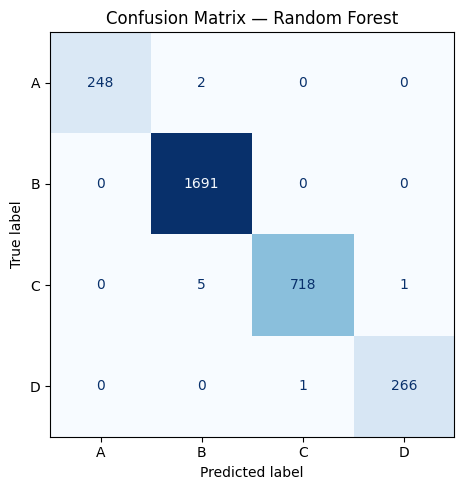

In [69]:
best_pred_enc = best_pipe.predict(X_val)
best_pred = label_encoder.inverse_transform(best_pred_enc)

print("Best model:", best_model_name)
print("\nClassification report:")
print(classification_report(y_val, best_pred, labels=CLASS_ORDER))

cm = confusion_matrix(y_val, best_pred, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## Ordinal error analysis

Not all mistakes are equally serious.

We therefore measure the **distance** between the true class and the predicted class:
- distance = 0 → correct prediction
- distance = 1 → adjacent error
- distance ≥ 2 → severe error

A strong model should mostly make local errors and avoid extreme jumps.

In [70]:
true_enc = label_encoder.transform(y_val)
pred_enc = label_encoder.transform(best_pred)

error_distance = np.abs(true_enc - pred_enc)

error_df = pd.DataFrame({
    "true": y_val.values,
    "pred": best_pred,
    "distance": error_distance
})

print("Error distance distribution:")
print(error_df["distance"].value_counts().sort_index())

severe_errors = error_df[error_df["distance"] >= 2]
print("\nSevere ordinal errors (distance >= 2):", len(severe_errors))
display(severe_errors.head(20))

Error distance distribution:
distance
0    2923
1       9
Name: count, dtype: int64

Severe ordinal errors (distance >= 2): 0


,true,pred,distance


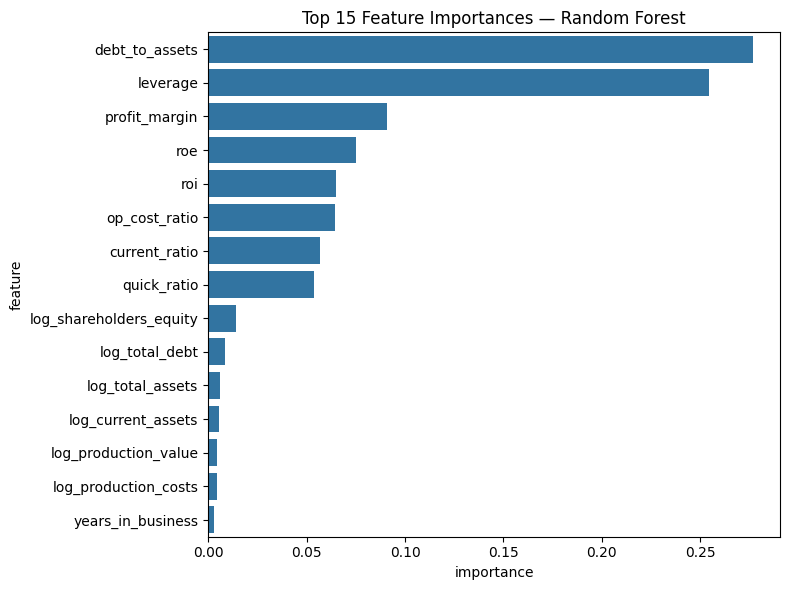

,feature,importance
4,debt_to_assets,0.276620
3,leverage,0.254434
2,profit_margin,0.091078
0,roe,0.074840
1,roi,0.065044
7,op_cost_ratio,0.064350
5,current_ratio,0.056925
6,quick_ratio,0.053751
11,log_shareholders_equity,0.014098
9,log_total_debt,0.008710


In [71]:
def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    cat_names = []
    if categorical_features:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    return numeric_features + cat_names

fitted_preprocessor = best_pipe.named_steps["preprocessor"]
feature_names = get_feature_names_from_preprocessor(
    fitted_preprocessor, numeric_features, categorical_features
)

model_obj = best_pipe.named_steps["model"]

if hasattr(model_obj, "feature_importances_"):
    importances = model_obj.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

    display(imp_df)

elif hasattr(model_obj, "coef_"):
    coef = np.mean(np.abs(model_obj.coef_), axis=0)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": coef
    }).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax)
    ax.set_title(f"Top 15 Absolute Coefficients — {best_model_name}")
    plt.tight_layout()
    plt.show()

    display(imp_df)

else:
    print("This model has no simple native feature importance.")

## Business interpretation

If the most important variables are profitability, leverage, liquidity, and debt burden indicators, the model is economically coherent:

- low profitability → weaker financial health
- high leverage / debt burden → greater distress
- weak liquidity → inability to absorb short-term shocks
- informative missingness in ROE / leverage can itself signal distress

This turns the model into a practical early-warning tool for creditors and investors.

In [72]:
final_table = comparison_df.copy()
final_table["rank"] = final_table["weighted_f1"].rank(ascending=False, method="dense")
final_table = final_table.sort_values("rank")

display(final_table)

,weighted_f1,macro_f1,accuracy,ordinal_mae,model,rank
0,0.996927,0.996331,0.996930,0.003070,Random Forest (tuned),1.0
1,0.995221,0.994312,0.995225,0.004775,XGBoost (tuned),2.0
2,0.993861,0.991640,0.993861,0.006139,HistGradientBoosting (tuned),3.0


## Final model decision

The final model is selected based on:

1. highest Weighted F1-score
2. good macro F1-score
3. low ordinal MAE
4. confusion matrix quality
5. low number of severe long-distance errors

This ensures that the chosen model is not only accurate, but also aligned with the ordinal structure of the financial health problem.

In [73]:
X_full = df_model[FEATURES].copy()
y_full = df_model[TARGET].copy()
y_full_enc = label_encoder.transform(y_full)

final_pipe = best_pipe
final_pipe.fit(X_full, y_full_enc)

print("Final model re-trained on full training data.")

Final model re-trained on full training data.


In [74]:
X_test = df_test_model[FEATURES].copy()

test_pred_enc = final_pipe.predict(X_test)
test_pred = label_encoder.inverse_transform(test_pred_enc)

submission = test_df.copy()

cols_to_keep = [c for c in ["company_id", "fiscal_year"] if c in submission.columns]
submission = submission[cols_to_keep].copy()
submission["financial_health_class"] = test_pred

display(submission.head())

,company_id,fiscal_year,financial_health_class
0,COMP_00000,2022,B
1,COMP_00000,2023,A
2,COMP_00001,2022,B
3,COMP_00001,2023,B
4,COMP_00002,2022,B


In [75]:
submission.to_csv("../data/final/challenge2_submission.csv", index=False)
print("Saved: ../data/final/challenge2_submission.csv")

Saved: ../data/final/challenge2_submission.csv


## Final conclusion

We built a leakage-safe temporal validation pipeline for Challenge 2 and compared:
- Logistic Regression
- Random Forest
- Gradient Boosting / XGBoost

The final model was selected primarily using **Weighted F1-score**, consistent with the challenge requirements, and then validated using:
- confusion matrix analysis
- macro F1
- ordinal error diagnostics

The final workflow translates the EDA into a robust and economically interpretable predictive system for financial health classification.